In [ ]:
import os 
import time

import pandas as pd
import numpy as np

import tensorflow.keras as keras
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler



In [ ]:
path = kagglehub.dataset_download("uciml/adult-census-income")
df = pd.read_csv(path)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [52]:
pcts = df['income_binary'].value_counts(normalize=True) * 100
pcts

<=50K    75.919044
>50K     24.080956
Name: income_binary, dtype: float64

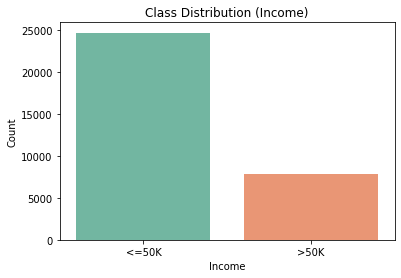

In [53]:
sns.countplot(data=df, x="income_binary", palette="Set2")
plt.title("Class Distribution (Income)")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

In [54]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32399.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32236.000000
mean,38.589216,1.897784e+05,10.080679,615.907773,87.303830,40.450428
std,13.647862,1.055500e+05,2.572720,2420.191974,402.960219,12.353748
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,14084.000000,4356.000000,99.000000


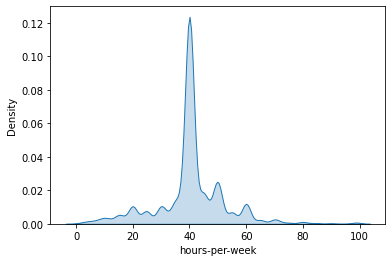

In [55]:
sns.kdeplot(data=df, x="hours-per-week", fill=True)
plt.show()

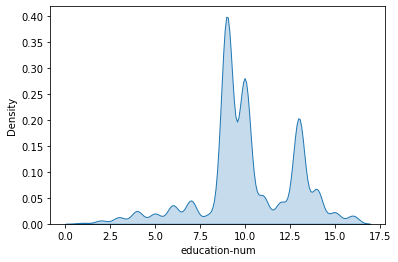

In [7]:
sns.kdeplot(data=df, x="education-num", fill=True)
plt.show()

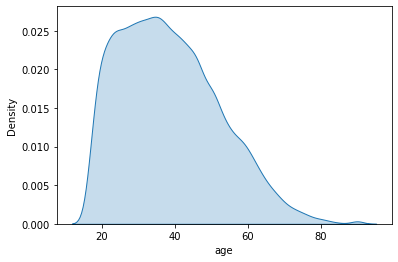

In [8]:
sns.kdeplot(data=df, x="age", fill=True)
plt.show()

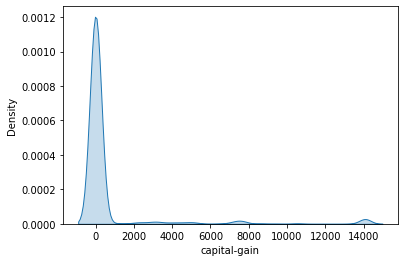

In [9]:
sns.kdeplot(data=df, x="capital-gain", fill=True)
plt.show()

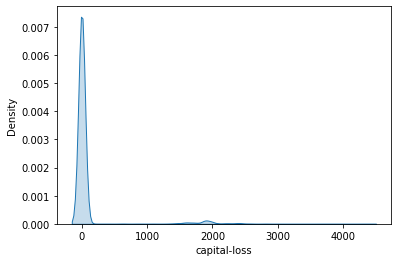

In [10]:
sns.kdeplot(data=df, x="capital-loss", fill=True)
plt.show()

In [11]:
print(df['income_binary'].unique().tolist())
print(df['sex_selfID'].unique().tolist())
print(df['race'].unique().tolist())
print(df['native-country'].unique().tolist())

['<=50K', '>50K']
['Non-Female', 'Female']
['White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Inuit', 'Other']
['United-States', 'Cuba', 'Jamaica', 'India', nan, 'Mexico', 'South', 'Puerto-Rico', 'Honduras', 'England', 'Canada', 'Germany', 'Iran', 'Philippines', 'Italy', 'Poland', 'Columbia', 'Cambodia', 'Thailand', 'Ecuador', 'Laos', 'Taiwan', 'Haiti', 'Portugal', 'Dominican-Republic', 'El-Salvador', 'France', 'Guatemala', 'China', 'Japan', 'Yugoslavia', 'Peru', 'Outlying-US(Guam-USVI-etc)', 'Scotland', 'Trinadad&Tobago', 'Greece', 'Nicaragua', 'Vietnam', 'Hong', 'Ireland', 'Hungary', 'Holand-Netherlands']


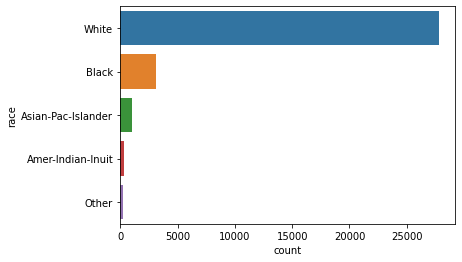

In [12]:
sns.countplot(y='race', data=df)
plt.show()

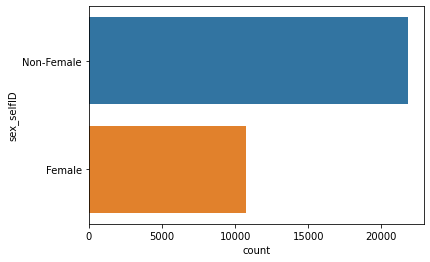

In [13]:
sns.countplot(y='sex_selfID', data=df)
plt.show()

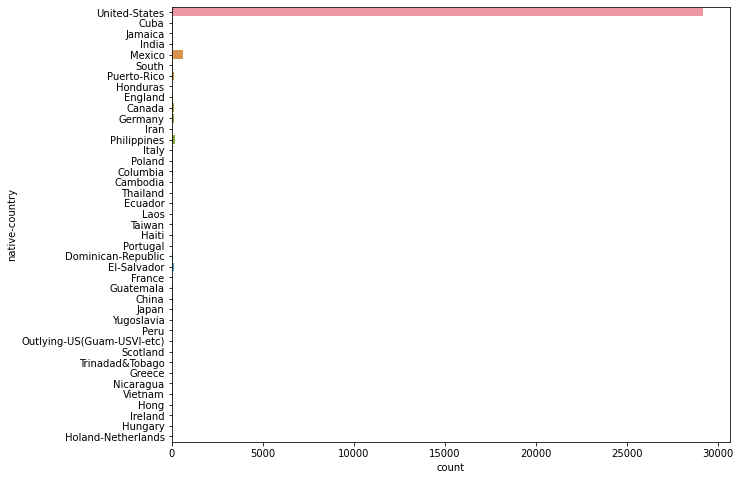

In [14]:
plt.figure(figsize=(10, 8))
sns.countplot(y='native-country', data=df)
plt.show()

In [15]:
print(df['native-country'].value_counts(normalize=True) * 100)

United-States                 91.218963
Mexico                         2.010757
Philippines                    0.619176
Germany                        0.428420
Canada                         0.378385
Puerto-Rico                    0.356495
El-Salvador                    0.331478
India                          0.312715
Cuba                           0.297079
England                        0.281443
Jamaica                        0.253299
South                          0.250172
China                          0.234536
Italy                          0.228282
Dominican-Republic             0.218900
Vietnam                        0.209519
Guatemala                      0.200138
Japan                          0.193883
Poland                         0.187629
Columbia                       0.184502
Taiwan                         0.159485
Haiti                          0.137595
Iran                           0.134467
Portugal                       0.115705
Nicaragua                      0.106323


In [ ]:
"""
df['is_female'] = df['sex_selfID'].map({'Female': 1, 'Non-Female': 0})
df['makes_over_50k'] = df['income_binary'].map({'>50K': 1, '<=50K': 0})
df['is_US_native'] = (df['native-country'] == 'United-States').astype(int)

print("CORRELATIONS", end="\n\n")
print(f"Is female / makes over 50K: {df['is_female'].corr(df['makes_over_50k'])}")
print(f"Is non-female / makes over 50K: {-df['is_female'].corr(df['makes_over_50k'])}")
print("\n")
print(f"Is non-US-native / makes over 50K: {df['is_US_native'].corr(df['makes_over_50k'])}")
print(f"Is US-native / makes over 50K: {-df['is_US_native'].corr(df['makes_over_50k'])}")
"""

'\ndf[\'is_female\'] = df[\'sex_selfID\'].map({\'Female\': 1, \'Non-Female\': 0})\ndf[\'makes_over_50k\'] = df[\'income_binary\'].map({\'>50K\': 1, \'<=50K\': 0})\ndf[\'is_US_native\'] = (df[\'native-country\'] == \'United-States\').astype(int)\n\nprint("CORRELATIONS", end="\n\n")\nprint(f"Is female / makes over 50K: {df[\'is_female\'].corr(df[\'makes_over_50k\'])}")\nprint(f"Is non-female / makes over 50K: {-df[\'is_female\'].corr(df[\'makes_over_50k\'])}")\nprint("\n")\nprint(f"Is non-US-native / makes over 50K: {df[\'is_US_native\'].corr(df[\'makes_over_50k\'])}")\nprint(f"Is US-native / makes over 50K: {-df[\'is_US_native\'].corr(df[\'makes_over_50k\'])}")\n'

In [17]:
#(pd.crosstab(df['is_female'], df['makes_over_50k'], normalize='index') * 100).round(2)

In [18]:
#(pd.crosstab(df['is_female'], df['is_US_native'], normalize='index') * 100).round(2)

In [19]:
df.isnull().sum()

age                162
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex_selfID           0
capital-gain         0
capital-loss         0
hours-per-week     325
native-country     583
income_binary        0
dtype: int64

In [20]:
df['occupation'].unique()

array(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', nan, 'Protective-serv', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)

### EDA Summary

The label distribution is roughly 75/25 (under/over 50K). That's a moderate imbalance, not severe, but enough that accuracy alone is misleading, since predicting "under 50K" for every example already scores ~75%. So we'll lean on F1 (and the subgroup metrics below) rather than accuracy.

The dataset is also ~67/33 male/female, versus roughly 50/50 in the real U.S. population, so the sample isn't fully representative on sex. That led me to check how sex relates to income: correlations between is_female and the label, plus the positive rate within each sex.

The gap is large: only ~11% of females earn over 50K versus ~31% of non-females, about a 90/10 split within the female subgroup alone. The risk this creates is that the model will have systematically lower recall on high-earning females than on high-earning males (it will miss the female positives). Because high-earning females are ~4% of the data, this stays invisible if we only look at aggregate accuracy. class_weight='balanced' addresses the global 75/25 imbalance, but it reweights the label marginal, not the sex gap—so we'll also measure recall by sex subgroup directly rather than assume balanced handled it.

Missing values are handled per column. Workclass and occupation are likely strong income predictors and hold the most missingness, so we fill with "Missing" and keep the rows rather than dropping them. Native-country is imputed with its mode ("United-States"), which already covers 91% of the data. Age and hours-per-week are imputed with the median: age is mildly right-skewed, and hours-per-week is sharply skewed with a spike at 40 and a long right tail, so median is more robust than mean for both.

### Data Preperation

In [56]:
df_lg = df.drop(columns=["fnlwgt", "education"])

In [57]:
df_lg.fillna(
    {
        "native-country": "United-States",
        "hours-per-week": df["hours-per-week"].median(),
        "age": df["age"].median(),
        "workclass" : "Missing",
        "occupation" : "Missing"
    },
    inplace=True,
)

In [58]:
df_lg.isnull().sum()

age               0
workclass         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex_selfID        0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income_binary     0
dtype: int64

In [59]:
df_lg['is_female'] = df_lg['sex_selfID'].map({'Female': 1, 'Non-Female': 0})
df_lg['makes_over_50k'] = df_lg['income_binary'].map({'>50K': 1, '<=50K': 0})
df_lg['is_US_native'] = (df_lg['native-country'] == 'United-States').astype(int)

In [60]:
df_lg = df_lg.drop(columns=["sex_selfID", "income_binary", "native-country"])

In [61]:
to_encode = ["workclass", "occupation", "marital-status", "relationship", "race"]
df_lg = pd.get_dummies(df_lg, columns=to_encode, dtype=int)

In [27]:
df_lg

,age,education-num,capital-gain,capital-loss,hours-per-week,is_female,makes_over_50k,is_US_native,workclass_Federal-gov,workclass_Local-gov,...,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Inuit,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,39.0,13,2174,0,40.0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,1
1,50.0,13,0,0,13.0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2,38.0,9,0,0,40.0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,1
3,53.0,7,0,0,40.0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,28.0,13,0,0,40.0,1,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27.0,12,0,0,38.0,1,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
32557,40.0,9,0,0,40.0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
32558,58.0,9,0,0,40.0,1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
32559,22.0,9,0,0,20.0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,1


###  General Cleaning
I dropped columns that aren't predictors: `fnlwgt` (a sampling weight) and the raw education string (redundant with `education-num`).

### NA Handling
I filled workclass and occupation NAs with "Missing" rather than dropping them: both are likely important predictors (occupation should correlate strongly with income, and public vs. private sector may cary signal too, since government salaries are generally lower than industry salaries for the same/similar role), and the volume of missingness made dropping wasteful. For the numeric columns `age` and `hours-per-week` I imputed with the median over the mean or mode, given the skew in both distributions. For `native-country` I imputed with "United-States"—which is the mode, at 91% of the data, so a separate missing category felt unnecessary.

### Encoding
Three variables became single binary columns. `income_binary` → `makes_over_50k`, via the >50K condition; `sex_selfID` → `is_female` (two-valued, so one indicator with the other as reference); `native-country` → `is_US_native`. Rather than one-hot encoding 40+ country levels, I collapsed native-country to a US/non-US indicator, since immigrant status plausibly carries the signal that matters here. A more rigorous version would bucket countries by region or GDP-per-capita band instead of flattening to one bit; I skipped that because the non-US share is only ~9% and the proxy is likely sufficient. 

### Train, Test, & Eval

In [62]:
label = 'makes_over_50k'

X = df_lg.drop(label, axis=1)
y = df_lg[label]

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30, 
    stratify=y, 
    random_state=316
)

In [64]:
y_train.describe()

count    22792.000000
mean         0.240830
std          0.427597
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: makes_over_50k, dtype: float64

In [65]:
y_test.describe()

count    9769.000000
mean        0.240762
std         0.427568
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: makes_over_50k, dtype: float64

In [1]:
continuous_cols = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']

scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols]  = scaler.transform(X_test[continuous_cols])

# because of warning
X_train = X_train.copy()
X_test  = X_test.copy()

NameError: name 'StandardScaler' is not defined

In [67]:
param_grid = {
    'C': np.logspace(-3, 3, 7),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': ['balanced', None]
}

model = LogisticRegression(max_iter=1000)

grid_search = GridSearchCV(
    estimator=model, 
    param_grid=param_grid,
    cv=5,
    scoring='f1'
)

grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Hyperparameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Score: 0.6765188383542207


In [69]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_pred = pd.Series(y_pred, index=y_test.index)

test_f1  = f1_score(y_test, y_pred, average='binary')
test_acc = accuracy_score(y_test, y_pred)

print("Test F1:", test_f1)
print("Test Accuracy:", test_acc)

Test F1: 0.6936516173672375
Test Accuracy: 0.8187122530453476


In [70]:
coefs = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': best_model.coef_[0]
}).sort_values('coefficient', ascending=False)

In [71]:
coefs

,feature,coefficient
43,relationship_Wife,1.214962
33,marital-status_Married-civ-spouse,1.212577
2,capital-gain,0.793915
1,education-num,0.720876
19,occupation_Exec-managerial,0.716316
29,occupation_Tech-support,0.566261
26,occupation_Prof-specialty,0.558487
27,occupation_Protective-serv,0.541651
7,workclass_Federal-gov,0.464175
32,marital-status_Married-AF-spouse,0.463703


In [72]:
print("--- Top Positive Drivers ---")
print(coefs.head(10))

# Top 10 strongest negative coefficients
print("\n--- Top Negative Drivers ---")
print(coefs.tail(10))

--- Top Positive Drivers ---
                              feature  coefficient
43                  relationship_Wife     1.214962
33  marital-status_Married-civ-spouse     1.212577
2                        capital-gain     0.793915
1                       education-num     0.720876
19         occupation_Exec-managerial     0.716316
29            occupation_Tech-support     0.566261
26          occupation_Prof-specialty     0.558487
27         occupation_Protective-serv     0.541651
7               workclass_Federal-gov     0.464175
32   marital-status_Married-AF-spouse     0.463703

--- Top Negative Drivers ---
                         feature  coefficient
25    occupation_Priv-house-serv    -0.509653
44        race_Amer-Indian-Inuit    -0.512101
36      marital-status_Separated    -0.544934
40   relationship_Other-relative    -0.616304
21  occupation_Handlers-cleaners    -0.655654
24      occupation_Other-service    -0.738490
5                      is_female    -0.738490
20    occupa

In [73]:
female_mask = X_test['is_female'] == 1
male_mask   = X_test['is_female'] == 0

recall_female = recall_score(y_test[female_mask], y_pred[female_mask])
recall_non_female = recall_score(y_test[male_mask], y_pred[male_mask])

print("Recall (female):", recall_female)
print("Recall (non-female):", recall_non_female)

Recall (female): 0.7535014005602241
Recall (non-female): 0.8701754385964913


## Neural Network


In [77]:
import tensorflow as tf
np.random.seed(316)
tf.random.set_seed(316)

# found out the hard way that i forgot this

In [78]:
# we can just reuse it
df_nn = df_lg
label = 'makes_over_50k'
X = df_nn.drop(label, axis=1)
y = df_nn[label]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=316
)

continuous_cols = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

scaler = StandardScaler()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols]  = scaler.transform(X_test[continuous_cols])

In [79]:
X_test_scaled.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,is_female,is_US_native,workclass_Federal-gov,workclass_Local-gov,workclass_Missing,...,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Inuit,race_Asian-Pac-Islander,race_Black,race_Other,race_White
8409,0.915542,1.133648,-0.254715,-0.218322,-0.037135,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
853,-0.925656,1.133648,-0.254715,-0.218322,-0.037135,1,1,0,0,0,...,1,0,0,0,0,0,0,0,0,1
29019,-0.925656,-1.977877,-0.254715,-0.218322,-0.200246,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
30715,-0.557417,1.133648,-0.254715,-0.218322,2.001748,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
10551,-0.041881,-0.422115,-0.254715,-0.218322,-0.037135,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1


In [ ]:
n_features = X_train_scaled.shape[1]

nn_model = keras.Sequential()

input_layer = keras.layers.InputLayer(input_shape=(n_features,))
nn_model.add(input_layer)

hidden_layer_1 = keras.layers.Dense(units=64, activation='relu')
nn_model.add(hidden_layer_1)

hidden_layer_2 = keras.layers.Dense(units=32, activation='relu')
nn_model.add(hidden_layer_2)

output_layer = keras.layers.Dense(units=1, activation='sigmoid')
nn_model.add(output_layer)

nn_model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_3 (Dense)              (None, 64)                3200      
_________________________________________________________________
dense_4 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_5 (Dense)              (None, 1)                 33        
Total params: 5,313
Trainable params: 5,313
Non-trainable params: 0
_________________________________________________________________


In [82]:
# 0.01 is a good starting point. We can't know how big a step
# the optimizer takes down the gradient on each update in advance.
# 0.01 is small enough to be stable but large enough to make progress
# in a reasonable number of epochs.
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

In [83]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

In [84]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

In [85]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


In [86]:
# imbalanced data, same as with our log reg, this is only gonna help for the general imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weights = dict(zip(np.unique(y_train), class_weights))

In [87]:
# we go 200 epochs so that we can see all the performance for epochs under that in our visualization
# edit: overfit, we now add early stopping

t0 = time.time() # start time

num_epochs = 200

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=num_epochs,
    verbose=0,
    validation_split=0.2,
    callbacks=[early_stop, ProgBarLoggerNEpochs(num_epochs, every_n=5)],
    class_weight=weights
)

t1 = time.time()

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [5/ 200], Loss: 0.3808, Accuracy: 0.8066, Val_loss: 0.3969, Val_accuracy: 0.7951
Epoch [10/ 200], Loss: 0.3716, Accuracy: 0.8113, Val_loss: 0.3834, Val_accuracy: 0.8008
Epoch [15/ 200], Loss: 0.3665, Accuracy: 0.8134, Val_loss: 0.3835, Val_accuracy: 0.8024
Epoch [20/ 200], Loss: 0.3633, Accuracy: 0.8163, Val_loss: 0.3940, Val_accuracy: 0.7980
Epoch [25/ 200], Loss: 0.3602, Accuracy: 0.8178, Val_loss: 0.3983, Val_accuracy: 0.7951
Epoch [30/ 200], Loss: 0.3581, Accuracy: 0.8177, Val_loss: 0.3685, Val_accuracy: 0.8131
Elapsed time: 38.20s


In [94]:
len(history.history['loss'])

31

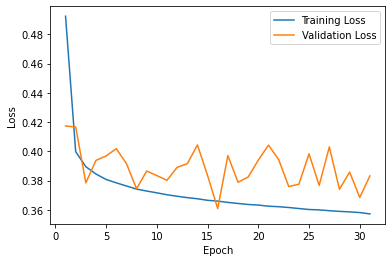

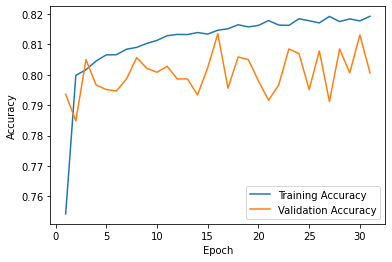

In [88]:
epochs_ran = len(history.history['loss'])

# Plot training and validation loss
plt.plot(range(1, epochs_ran + 1), history.history['loss'], label='Training Loss')
plt.plot(range(1, epochs_ran + 1), history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.plot(range(1, epochs_ran + 1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, epochs_ran + 1), history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
y_prob_nn = nn_model.predict(X_test_scaled)
y_pred_nn = (y_prob_nn.ravel() >= 0.5).astype(int) 

In [90]:
# Compute accuracy and F1 score for the neural network and print the results
nn_f1 = f1_score(y_test, y_pred_nn, average='binary')
nn_acc = accuracy_score(y_test, y_pred_nn)

In [91]:
print("F1:", nn_f1)
print("Accuracy:", nn_acc)

F1: 0.7056922248159454
Accuracy: 0.8322243832531477


In [92]:
female_mask_nn = X_test_scaled['is_female'] == 1
male_mask_nn = X_test_scaled['is_female'] == 0

recall_female_nn = recall_score(y_test[female_mask_nn], y_pred_nn[female_mask_nn])
recall_non_female_nn = recall_score(y_test[male_mask_nn], y_pred_nn[male_mask_nn])

print("Recall (female):", recall_female_nn)
print("Recall (non-female):", recall_non_female_nn)

Recall (female): 0.7619047619047619
Recall (non-female): 0.8486215538847118


In [93]:
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Logistic Regression Model': [round(test_acc, 4), round(test_f1, 4)],
    'Neural Network': [round(nn_acc, 4), round(nn_f1, 4)]
})

subgroup_recall = pd.DataFrame({
    'Recall by Subgroup': ['Female', 'Non-female'],
    'Logistic Regression Model': [round(recall_female, 4), round(recall_non_female, 4)],
    'Neural Network': [round(recall_female_nn, 4), round(recall_non_female_nn, 4)]
})

print("--- Results by Model ---")
print(results.to_string(index=False))
print("\n")

print("--- Results by Subgroup ---")
print(subgroup_recall.to_string(index=False))


--- Results by Model ---
   Metric  Logistic Regression Model  Neural Network
 Accuracy                     0.8187          0.8322
 F1 Score                     0.6937          0.7057


--- Results by Subgroup ---
Recall by Subgroup  Logistic Regression Model  Neural Network
            Female                     0.7535          0.7619
        Non-female                     0.8702          0.8486
